# TabPFN tutorial 

[TabPFN](https://www.nature.com/articles/s41586-024-08328-6) is a tabular foundation model based on Transformers, which can deal with both **regression** and **classification** problems. `Mother` has `TabPFN` internally implemented, and you can use the models by installing the `mother[tabpfn]` (Please see the [installation](http://github.com/bayer-int/mother-ml?tab=readme-ov-file#install) page for details).

This example shows how to use: 

1. [`TabPFNClassifierMother`](##-1.-TabPFNClassifierMother)
2. [`TabPFNRegressorMother`](##-2.-TabPFNRegressorMother)
3. [`TabPFNEmbeddingTransformer`](##-3.-TabPFNEmbeddingTransformer)
4. [`Mother` optimisation with `TabPFN`](##-4.-Mother-optimisation-with-TabPFN)
5. [_SHAP_ explainability for `TabPFN`](##-5.-SHAP-explainability-for-TabPFN)

### <span style="color:red">_Note_</span>
According to the authors, `TabPFN` is primarily designed for small-to medium-sized tabular data (**max 10,000 samples and 500 features**). Users can give a larger dataset by using [`ignore_pretraining_limits=True`](https://github.com/PriorLabs/TabPFN/blob/0a9a75a5c99afc531ed5e7df155f11a572c51278/src/tabpfn/regressor.py#L185) option, but the running time and the performance could differ from the paper. In this tutorial, we only use a small size of features by generating one type of fingerprint.

In [1]:
%load_ext autoreload
%autoreload 2

# scikit-learn
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import train_test_split, GroupKFold, KFold

# mother
from mother import feature_generation as fg
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer
import mother.optimization as opt
from mother import cv as cv_module
import mother.pipeline_utils as mother_takes_care
import mother.ml as ml
from mother.ml.models.m_tabpfn import TabPFNClassifierMother, TabPFNRegressorMother, TabPFNEmbeddingTransformer

# optuna
from optuna.visualization import plot_optimization_history

# additional libraries for data handling
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# others
import logging, warnings

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
warnings.filterwarnings("ignore")

In [2]:
print(ml.get_available_algorithms())
print(*ml.get_supported_models(), sep=" -- ")

['randomforest', 'catboost', 'tabpfn', 'lasso']
RandomForestClassifierMother -- RandomForestRegressorMother -- CatboostClassifierMother -- CatboostGaussianProcessRegressorMother -- CatboostRegressorMother -- TabPFNClassifierMother -- TabPFNRegressorMother -- LassoClassifierBinaryMother -- LassoClassifierMulticlassMother -- LassoRegressorMother


In [3]:
print(ml.get_model_class("TabPFNClassifierMother"))
print(ml.describe_model("TabPFNClassifierMother"))

<class 'mother.ml.models.m_tabpfn.TabPFNClassifierMother'>
## TabPFNClassifierMother

 A custom implementation of TabPFNClassifier with extended functionality for hyperparameter tuning.

This class extends the TabPFNClassifier and integrates with the Mother framework to provide
dynamic hyperparameter tuning using Optuna.

Attributes
----------

Methods
-------
default_parameters(prefix: str = "") -> dict
    Returns the default parameters for the TabPFNClassifier.

get_params() -> dict
    Returns the current parameters for the TabPFNClassifier.

set_params(**params) -> None
    Sets the given parameters with new values (applicable only when the model is not fitted).

Example
-------
>>> from optuna.trial import Trial
>>> from mother.ml.m_tabpfn import TabPFNClassifierrMother
>>> import pandas as pd
>>> import numpy as np
>>> trial = Trial(...)
>>> X = pd.DataFrame(np.random.rand(100, 10))
>>> y = pd.Series(np.random.rand(100))
>>> classifier = TabPFNClassifierMother()
>>> hyperparams 

## 1. `TabPFNClassifierMother`

### 1-1. Data preprocessing

Load the data from the input file. The data file contains a column with the molecule information (`smiles`) and a column with the target labels (`cat_col`).

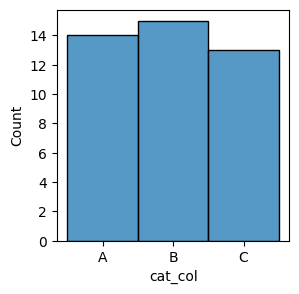

,iupac,smiles,expt,calc,int_col,cat_col,float_col
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01,-9.625,1.0,A,1.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87,-6.219,2.0,B,1.02
4,heptan-1-ol,CCCCCCCO,-4.21,-2.917,5.0,B,1.05
5,"3,5-dimethylphenol",Cc1cc(cc(c1)O)C,-6.27,-5.444,6.0,C,1.06
6,"2,3-dimethylbutane",CC(C)C(C)C,2.34,2.468,7.0,A,1.07


In [4]:
# load data
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",").dropna()  # drop NA in the cat_col column

# plot the classes
plt.figure(figsize=(3, 3))
sns.histplot(data, x="cat_col")
plt.show()

data.head()

Here, we use `ChemicalDescriptors` from `mother.feature_generation` to create the structured input data for `cat_col` prediction. More information about how to create fingerprints from SMILES from `Mother` is in [example_feature_selection](https://github.com/bayer-int/mother-ml/blob/master/examples/notebooks/example_feature_selection.ipynb).

In [4]:
def get_data(data: pd.DataFrame, y_col_name: str, split_ratio: float = 0.3):
    # process smiles data into features
    preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
        [
            (
                "smiles_standardizer",
                StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
            ),
            ("smiles_to_mol", SmilesToMolTransformer()),
            # Add other column transformations here if needed
        ],
        memory=None,
    ).set_output(transform="pandas")

    structure_data: pd.Series = data["smiles"]
    mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

    feature_generator = sklearn_pipeline.FeatureUnion(
        transformer_list=[
            ("desc", fg.ChemicalDescriptors()),
        ],
    ).set_output(transform="pandas")

    features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"]).set_index(data.index)
    print(f"Collected data (n={features.shape[0]}) has {features.shape[1]} features.")

    # Random split of given data into the train and test sets with a ratio of 0.3
    return train_test_split(features, data[y_col_name], test_size=split_ratio, random_state=42)


# Regenerate the data with the best number of features
X_train, X_test, y_train, y_test = get_data(data=data, y_col_name="cat_col")
print(f"Train n={X_train.shape[0]} / Test n={X_test.shape[0]}")

2025-07-21 06:25:46,356 - mother.preprocessing.core - INFO - Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[06:25:46] Initializing Normalizer
[06:25:46] Initializing Normalizer
[06:25:46] Initializing MetalDisconnector
[06:25:46] Initializing Normalizer


Collected data (n=42) has 217 features.
Train n=29 / Test n=13


### 1-2. Model Training
Now, we train a `TabPFNClassifierMother` model with the train set. `TabPFNClassifierMother` follows the same scheme as `sklearn.base.BaseEstimator`. 

In [7]:
cls = TabPFNClassifierMother(n_estimators=4)  # ensemble with 4 models
# train
cls.fit(X_train, y_train)
# test
y_pred = cls.predict(X_test)
pd.DataFrame({"y_test": y_test, "y_pred": y_pred}).head()

,y_test,y_pred
33,A,A
20,C,A
12,A,B
34,B,B
6,A,A


## 2. `TabPFNRegressorMother`
### 2-1. Data preprocessing

Load the data from the input file. The data file contains a column with the molecule information (`smiles`) and a column with the target labels (`cat_col`).

In [5]:
# Regenerate the data with the best number of features
X_train, X_test, y_train, y_test = get_data(data=data, y_col_name="expt")
print(f"Train n={X_train.shape[0]} / Test n={X_test.shape[0]}")

2025-07-21 06:25:49,742 - mother.preprocessing.core - INFO - Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[06:25:49] Initializing Normalizer
[06:25:49] Initializing Normalizer
[06:25:49] Initializing MetalDisconnector
[06:25:49] Initializing Normalizer


Collected data (n=42) has 217 features.
Train n=29 / Test n=13


### 2-2. Model Training
Now, we train a `TabPFNRegressorMother` model with the train set. `TabPFNRegressorMother` follows the same scheme as `sklearn.base.BaseEstimator`. 

In [6]:
reg = TabPFNRegressorMother(n_estimators=4)  # ensemble with 4 models
# train
reg.fit(X_train, y_train)
# test
y_pred = reg.predict(X_test)
pd.DataFrame({"y_test": y_test, "y_pred": y_pred}).head()

,y_test,y_pred
33,-9.29,-9.492471
20,-6.34,-7.522819
12,-4.33,-2.581163
34,-4.07,-4.549716
6,2.34,-0.328240


### 2-3. Uncertainty Estimation

`TabPFNRegressor` supports a quantile estimation which can be used for uncertainty estimation. To obtain the uncertainty value for each test data point, please use `predict_uncertainty`. The result is returned in a `pandas.DataFrame` whose columns are:
- `mean_predictions`: predicted value
- `total_uncertainty`: estimated uncertainty for the data point. The uncertainty is calculated using [interquartile range](https://en.wikipedia.org/wiki/Interquartile_range) based on the estimated quantiles. 

### <span style="color:red">_Note_</span>
We have a separate example notebook for the uncertainty quantification and active learning with TabPFN. Please, find details about `TabPFNRegressorMother` uncertainty quantification and how to use it in the active learning format. 

In [ ]:
y_uncertainty = reg.predict_uncertainty(X_test)
y_uncertainty["y_test"] = y_test
y_uncertainty["absolute_err"] = abs(y_uncertainty["mean_predictions"] - y_uncertainty["y_test"])

y_uncertainty.head()

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty,y_test,absolute_err
33,-9.492471,None,None,3.113751,-9.29,0.202471
20,-7.522819,None,None,4.016447,-6.34,1.182819
12,-2.581163,None,None,2.101869,-4.33,1.748837
34,-4.549716,None,None,1.804044,-4.07,0.479716
6,-0.328240,None,None,1.950846,2.34,2.668240


When `return_quantiles=True`, users can also obtain each quantile estimation as well as the estimated uncertainty. By default, `TabPFNRegressorMother` calculates quantiles of 0.25, 0.5, and 0.75 but users can provide more quantiles with the `quantiles` option.

In [ ]:
y_uncertainty, pred_quantiles = reg.predict_uncertainty(X_test, quantiles=[0.1, 0.8], return_quantiles=True)

pd.DataFrame(pred_quantiles, index=X_test.index, columns=[f"q_{q}" for q in [0.1, 0.25, 0.5, 0.75, 0.8]]).head()

,q_0.1,q_0.25,q_0.5,q_0.75,q_0.8
33,-12.522345,-11.041426,-9.568768,-7.927675,-7.473974
20,-11.807140,-9.296055,-7.052974,-5.279608,-4.883726
12,-4.606162,-3.603553,-2.539096,-1.501685,-1.244600
34,-6.461033,-5.373263,-4.413362,-3.569219,-3.363317
6,-2.229301,-1.272817,-0.276548,0.678029,0.912056


In [12]:
y_uncertainty.head()

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
33,-9.492471,None,None,3.113751
20,-7.522819,None,None,4.016447
12,-2.581163,None,None,2.101869
34,-4.549716,None,None,1.804044
6,-0.328240,None,None,1.950846


## 3. `TabPFNEmbeddingTransformer`

TabPFN models also support embedding extraction from a trained model. `Mother` provides `TabPFNEmbeddingTransformer` to handle the embeding extraction more conveniently. 

### 3-1. get embeddings from a trained model 

#### 3-1-1. get the full embeddings
Users can provide a trained model with the `model=` option. Please, note that each ensemble model creates a 192 dimension of embeddings (**Please set `use_kfold=False` if you want to give a trained model**). In this tutorial, we created a `TabPFRNRegressorMother` with `n_estimators=4`, therefore `TabPFNEmbeddingTransformer` outputs a 768 dimension of embeddings.  

In [ ]:
embedding_transformer = TabPFNEmbeddingTransformer(model=reg, use_kfold=False, random_state=42)
X_test_embeddings = embedding_transformer.transform(X=X_test)
print(f"{X_test_embeddings.shape} {X_test.shape} {reg.n_estimators}")

(13, 768) (13, 217) 4


#### 3-1-2. get only the best embeddings (reduced dimension)
In addition, users can get the best embeddings out of embeddings from all ensemble models by setting `only_best_embeddings=True`. The best embeddings have a fixed dimenstion of 192. The best embeddings are chosen by calculating silhouette score (classification) or using a random forest regressor (regression). **To use this option, users need to run `fit_transform` with the `only_best_embeddings=True` option even if a trained model is given.** `TabPFNEmbeddingTransformer` learns which estimator returns the best embedding for the training data via this step and returns embeddings only from the estimator (dim=192).

In [8]:
embedding_transformer = TabPFNEmbeddingTransformer(model=reg, use_kfold=False, random_state=42)
embedding_transformer.fit_transform(X_train, y_train, only_best_embeddings=True)
X_test_embeddings = embedding_transformer.transform(X=X_test, only_best_embeddings=True)
print(f"{X_test_embeddings.shape} {X_test.shape} {reg.n_estimators}")

2025-07-21 06:29:34,431 - mother.ml.models.m_tabpfn - INFO - A pre-fitted model has been given. The new data will not be used for fitting the model.


(13, 192) (13, 217) 4


### 3-2. get embeddings without a trained model 

`TabPFNEmbeddingTransformer` can also generate embeddings without a trained model. Users can only clarify `model_type` and set `use_kfold=True`, then `TabPFNEmbeddingTransformer` automatically creates an appropriate `TabPFN` model. <span style="color:red">We implemented a new algorithm to obtain embeddings without a trained model via _K-fold_ cross validation in order to prevent data leakage</span>. 

The `fit_transform` function trains the created model and returns the generated embeddings.

In [14]:
embedding_transformer = TabPFNEmbeddingTransformer(model_type="regression", use_kfold=True, n_folds=5, random_state=42)
X_train_embedding = embedding_transformer.fit_transform(X_train, y_train, only_best_embeddings=True)
print(f"{X_train_embedding.shape} {X_train.shape} {reg.n_estimators}")

2025-07-20 12:45:36,423 - root - INFO - Run K-fold to fit the model and obtain the embeddings with K=5


(29, 192) (29, 217) 4


You can visualise the generated embeddings in a 2D space using PCA.

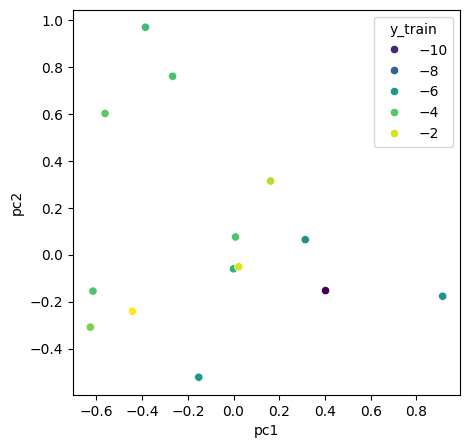

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(X_train_embedding)
pca_res = pd.DataFrame(pca_res, columns=["pc1", "pc2"])
pca_res["y_train"] = y_train

fig, ax = plt.subplots(1, figsize=(5, 5))
sns.scatterplot(data=pca_res, x="pc1", y="pc2", hue="y_train", palette="viridis", ax=ax)
sns.move_legend(ax, loc="upper right", bbox_to_anchor=(1.0, 1))
plt.show()

## 4. `Mother` optimisation with `TabPFN` 

In this section, we explain how to optimise `TabPFN` models using `mother.optimization.MotherTuner` for **hyperparameter tuning**. This section assumes that users have baseline knowledge about the followings:
- [Feature selection pipeline using `Mother`](https://github.com/bayer-int/mother-ml/blob/tabpfn/examples/notebooks/example_feature_selection.ipynb)
- [Hyperparameter optimisation customisation using `Mother`](https://github.com/bayer-int/mother-ml/blob/tabpfn/examples/notebooks/custom_hyperparameter_optimization.ipynb)
- [Cross validation methods (`KFold` and `GroupKFold`)](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators)
- [Tanimoto clustering](https://github.com/bayer-int/mother-ml/blob/tabpfn/examples/notebooks/example_clustering.ipynb)

### 4-1. Data preparation  

We again use the `cat_col` column for the target value to optimise `TabPFNRegressorMoether`. However, for the input data, molecules generated from SMILES are directly used instead of the features because we optimise the feature selection pipeline as well. 

In [9]:
def get_data_with_mol(data: pd.DataFrame, y_col_name: str):
    # process smiles data into features
    preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
        [
            (
                "smiles_standardizer",
                StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
            ),
            ("smiles_to_mol", SmilesToMolTransformer()),
            # Add other column transformations here if needed
        ],
        memory=None,
    ).set_output(transform="pandas")

    structure_data: pd.Series = data["smiles"]
    mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

    feature_generator = sklearn_pipeline.FeatureUnion(
        transformer_list=[
            ("desc", fg.ChemicalDescriptors()),
        ],
    ).set_output(transform="pandas")

    features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"]).set_index(data.index)
    print(f"Collected data (n={features.shape[0]}) has {features.shape[1]} features.")

    return features, mol_data, data[y_col_name]  # Return molecules


features, mol_data, y_true = get_data_with_mol(data, "expt")
mol_data.head()

2025-07-21 06:42:10,860 - mother.preprocessing.core - INFO - Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[06:42:10] Initializing Normalizer
[06:42:10] Initializing Normalizer
[06:42:10] Initializing MetalDisconnector
[06:42:10] Initializing Normalizer


Collected data (n=42) has 217 features.


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x7116a17f7f40>
1,<rdkit.Chem.rdchem.Mol object at 0x7116a1834890>
2,<rdkit.Chem.rdchem.Mol object at 0x7116a1834040>
3,<rdkit.Chem.rdchem.Mol object at 0x7116a17d4120>
4,<rdkit.Chem.rdchem.Mol object at 0x7116a17d40b0>


We use [`GroupKFold`](https://scikit-learn.org/stable/modules/cross_validation.html#group-k-fold) for cross validation, which requires the group information for better generalisation. Here, we use _Tanimoto_ clusters of molecules as the group information.

In [10]:
# cv grouping
cv = GroupKFold(n_splits=5)
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)
groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])
groups = groups.astype(int)
groups.head()

2025-07-21 06:42:13,273 - mother.feature_generation.fp_gen - INFO - Creating fingerprint generator 'MorganFP'
2025-07-21 06:42:13,275 - mother.cv.cv_methods - INFO - Applying clustering with Tanimoto similarity: 0.3
2025-07-21 06:42:13,277 - mother.cv.cv_methods - INFO - Found: 29 clusters


,tanimoto-group
0,0
1,1
2,2
3,3
4,4


### 4-2. Pipeline setup

`mother.ml.PipelineWithHyperparameterRooting` provides an automatic set up of `sklearn.pipeline.Pipeline` for hyperparameter optimisation meaning that it collects all optimisable hyperparameters from each step during the `optuna` optimisation. (Please find details about the `Mother` pipeline setup [here](https://github.com/bayer-int/mother-ml/blob/tabpfn/examples/notebooks/example_pipeline_with_settings.ipynb).)

As mentioned, we also optimise the feature selection pipeline by giving the `DROP_UNIMPORTANT` flag in the `feature_selection_flags` which filters the generated features out with a given threshold hyperparameter. 



In [ ]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 1e-5,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "feature_selection_type": "permutation",
    "target_type": "single_target",
    "type": "regression",
}
pipeline_settings = {
    "remainder": "drop",
    "verbose_feature_names_out": False,
}
model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings,
                pipeline_settings=pipeline_settings,
                cv=KFold(n_splits=5, random_state=42),
            ).set_output(transform="pandas"),
        ),
        ("ml_model", TabPFNRegressorMother()),
    ]
)

2025-07-21 06:42:16,037 - mother.pipeline_utils - INFO - Creating feature selection pipeline for numeric columns.
2025-07-21 06:42:16,061 - mother.pipeline_utils - INFO - The default correlation method is used
2025-07-21 06:42:16,061 - mother.pipeline_utils - INFO - Boruta usage: False
2025-07-21 06:42:16,062 - mother.ml.utils - INFO - Using 'RMSE' as loss function.
2025-07-21 06:42:16,077 - mother.pipeline_utils - INFO - Setting up permutation importance feature selection


In our pipeline, three hyperparameters will be optimised: `threshold` from the feature selector, and `n_estimators`, `softmax_temparature` and `ignore_pretraining_limits` from the `TabPFNRegressorMother`. 

In [12]:
model.default_parameters()

{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308,
 'ml_model__n_estimators': 4,
 'ml_model__softmax_temperature': 1,
 'ml_model__ignore_pretraining_limits': False}

For the optimisation tuner, we only set a very small number for `n_trials_optuna`, `n_startup_trials`, and `n_threads_optuna`. In actual use cases, users should increase these numbers so the tuner can investigate a wide range of hyperparameter space. (Please note that `Mother` uses [`TPESampler`](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html) for parameter value sampling by default.)

In [ ]:
tuner = opt.MotherTuner(
    scorer="r2",
    n_trials_optuna=5,  # The number of trials for each process.
    n_startup_trials=1,  # The number of random sampling will be performed instead of the TPE sampling until this number
    n_threads_optuna=2,  # parallel threads for cross-validation evaluation
)

model_tuned = tuner.optimize(
    model,
    features,
    y_true,
    cross_validation=cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    groups=groups.iloc[:, 0],
)

2025-07-20 12:51:43,187 - mother.optimization.core - INFO - Setting up Optuna to optimize hyperparameters with direction: 2
2025-07-20 12:51:43,188 - optuna.storages._in_memory - INFO - A new study created in memory with name: no-name-2ceb4c2f-f03a-4887-b566-33c18b0b87db
2025-07-20 12:51:43,189 - mother.optimization.core - INFO - Running hyperparameter optimization with 5 trials
2025-07-20 12:51:43,191 - mother.ml.models.m_tabpfn - INFO - Suggested parameters in trial 0: {'n_estimators': 2, 'softmax_temperature': 1, 'average_before_softmax': True}


2025-07-20 12:52:43,881 - mother.optimization.core - INFO - Trial 0, cv score: [0.3606394  0.2850478  0.88582708 0.44583514 0.57252709]
2025-07-20 12:52:43,882 - optuna.study.study - INFO - Trial 0 finished with value: 0.5099753020615103 and parameters: {'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__n_estimators': 2, 'ml_model__softmax_temperature': 1.0, 'ml_model__average_before_softmax': True}. Best is trial 0 with value: 0.5099753020615103.
2025-07-20 12:52:44,102 - mother.ml.models.m_tabpfn - INFO - Suggested parameters in trial 1: {'n_estimators': 2, 'softmax_temperature': 0.6167183367513475, 'average_before_softmax': True}
2025-07-20 12:53:46,638 - mother.optimization.core - INFO - Trial 1, cv score: [0.37454934 0.19874926 0.88860462 0.45865355 0.56343703]
2025-07-20 12:53:46,639 - optuna.study.study - INFO - Trial 1 finished with value: 0.49679876007267687 and parameters: {'feature_selector__feature_selector__importance

{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__n_estimators': 2, 'ml_model__softmax_temperature': 1.0, 'ml_model__average_before_softmax': True}


2025-07-20 12:56:37,267 - mother.ml.estimators - INFO - Feature importances have been turned into percentiles
2025-07-20 12:56:37,268 - mother.ml.estimators - INFO - Finished permutation feature importance calculation for selection
2025-07-20 12:56:37,269 - mother.ml.estimators - INFO - Initialized permutation feature importance estimator
2025-07-20 12:56:37,430 - mother.optimization.core - INFO - Training completed


Users can plot the optimisation result. Here, we got the best parameters at the first trial.

In [29]:
plot_optimization_history(tuner.study)

## 5. _SHAP_ explainability for `TabPFN`

TabPFN supports an extension to calculate [_SHAP_](https://shap.readthedocs.io/en/latest/) score of the trained model via [TabPFN-extension](https://github.com/priorlabs/tabpfn-extensions).

The extension should be additionally installed:
```
pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
```

Here, we calculate _SHAP_ scores for the traine `TabPFNRegressorMother` model from the previous section to investigate the most impactful factor upon the regression output. 

[SHAP tutorial](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html) pages a more detailed overview about how to interpret the results. 

2025-07-18 13:34:38,283 - root - INFO - Using TabPFN package
2025-07-18 13:34:38,283 - root - INFO - Using TabPFN package
PermutationExplainer explainer: 14it [29:31, 136.30s/it]                        


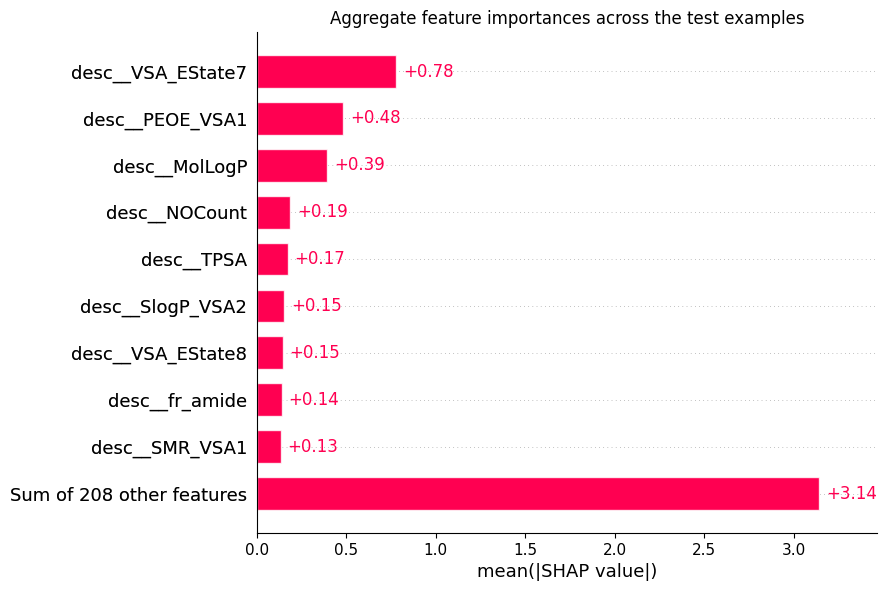

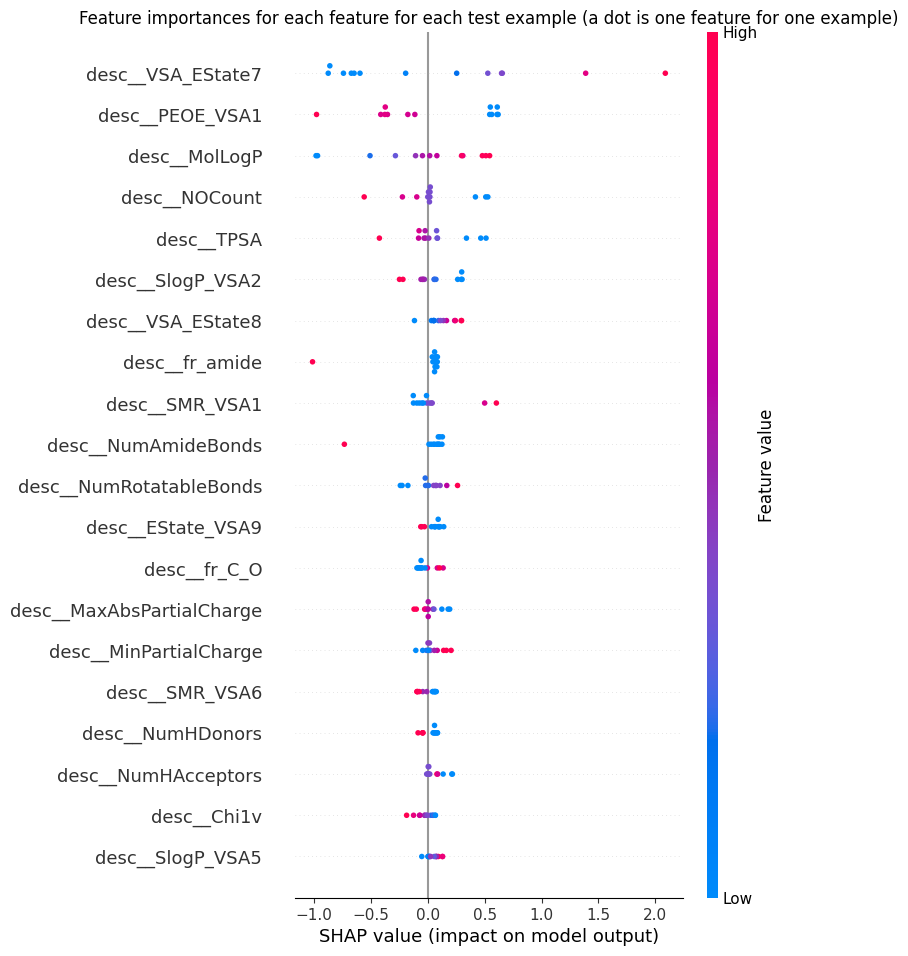

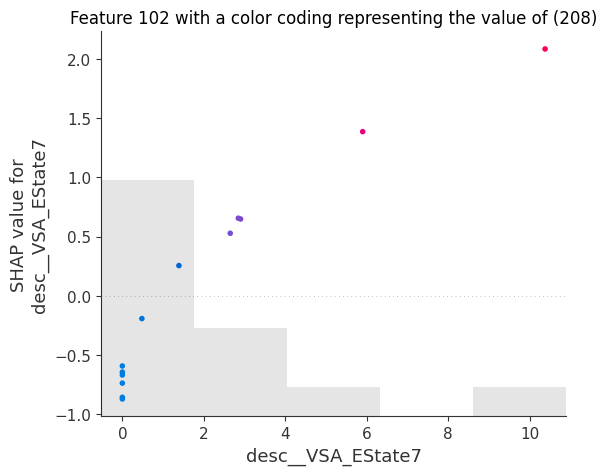

In [ ]:
from tabpfn_extensions import interpretability

# Calculate SHAP values
shap_values = interpretability.shap.get_shap_values(
    estimator=reg, test_x=X_test, attribute_names=X_train.columns.tolist(), algorithm="permutation", max_evals=1000
)

# Create visualization
interpretability.shap.plot_shap(shap_values)